In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.fft import fft

### Исследование данных

Краткая интерпретация признаков:
- HUFL / HUFL.1 (High UseFul Load): Высокая нагрузка (полезная) для 1-го и 2-го трансформаторов.
- HULL / HULL.1 (High UseLess Load): Высокая нагрузка (бесполезная).
- MUFL / MUFL.1 (Medium UseFul Load): Средняя нагрузка (полезная).
- MULL / MULL.1 (Medium UseLess Load): Средняя нагрузка (бесполезная).
- LUFL / LUFL.1 (Low UseFul Load): Низкая нагрузка (полезная).
- LULL / LULL.1 (Low UseLess Load): Низкая нагрузка (бесполезная).
- OT / OT.1 (Oil Temperature): Температура масла (Целевой признак).

ОПИСАНИЕ ДАТАСЕТА И РАЗМЕР ВЫБОРКИ
Форма датасета (строк, колонок): (17420, 14)
Временной охват: с 2016-07-01 00:00:00 по 2018-06-26 19:00:00
Количество пропущенных значений:
HUFL      0
HULL      0
MUFL      0
MULL      0
LUFL      0
LULL      0
OT        0
HUFL.1    0
HULL.1    0
MUFL.1    0
MULL.1    0
LUFL.1    0
LULL.1    0
OT.1      0
dtype: int64

АНАЛИЗ СТАЦИОНАРНОСТИ(ADF)
Нулевая гипотеза (H0): Ряд нестационарен (имеет единичный корень).
Альтернативная гипотеза (H1): Ряд стационарен.

Тестируем признак: OT
  ADF Statistic: -3.4880
  p-value: 8.3016e-03
  Критические значения:
    1%: -3.4307
    5%: -2.8617
    10%: -2.5669
--> Итог для OT: p-value <= 0.05. Нулевая гипотеза отвергается. Ряд СТАЦИОНАРНЫЙ.
------------------------------
Тестируем признак: OT.1
  ADF Statistic: -3.5971
  p-value: 5.8161e-03
  Критические значения:
    1%: -3.4307
    5%: -2.8617
    10%: -2.5669
--> Итог для OT.1: p-value <= 0.05. Нулевая гипотеза отвергается. Ряд СТАЦИОНАРНЫЙ.
------------------

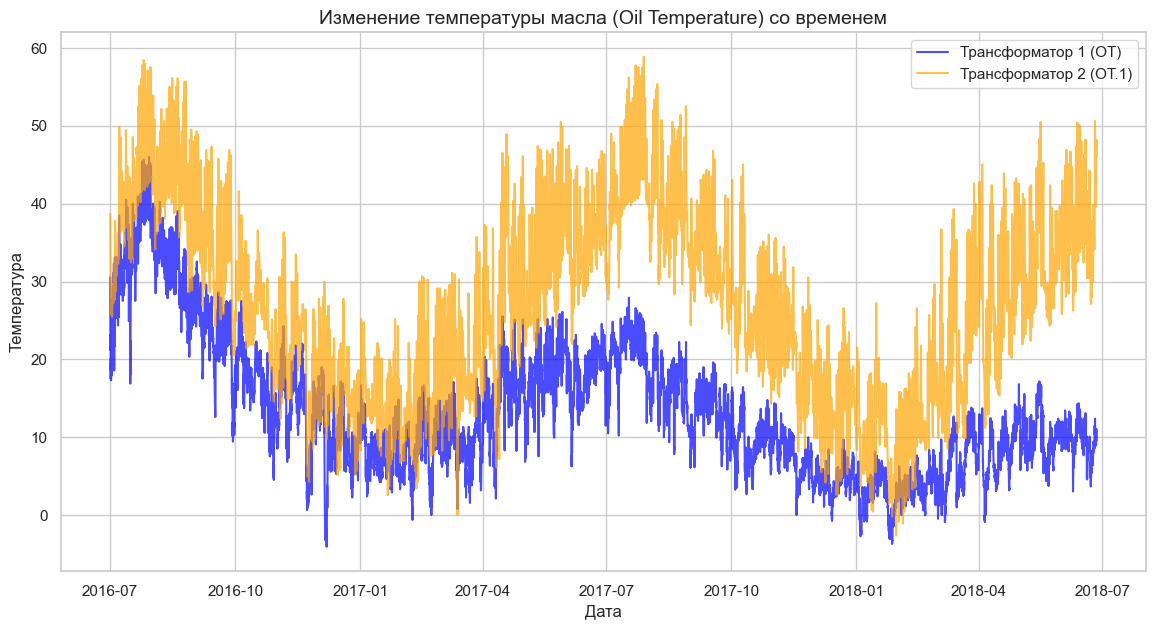

C:\Users\Egorgorgor\AppData\Local\Temp\ipykernel_26516\1741251342.py:45: FutureWarning: first is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  df_short = df.first('30D')


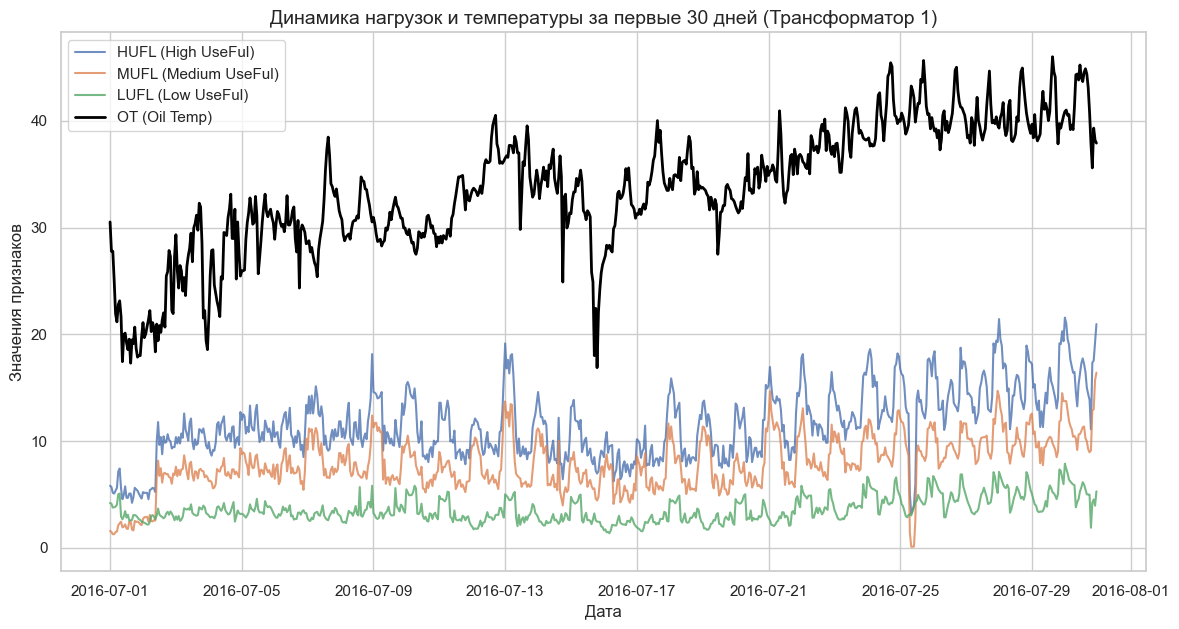

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)

df = pd.read_csv('ETTh.csv', parse_dates=['date'], index_col='date')

print("ОПИСАНИЕ ДАТАСЕТА И РАЗМЕР ВЫБОРКИ")
print(f"Форма датасета (строк, колонок): {df.shape}")
print(f"Временной охват: с {df.index.min()} по {df.index.max()}")
print(f"Количество пропущенных значений:\n{df.isnull().sum()}\n")

print("АНАЛИЗ СТАЦИОНАРНОСТИ(ADF)")
print("Нулевая гипотеза (H0): Ряд нестационарен (имеет единичный корень).")
print("Альтернативная гипотеза (H1): Ряд стационарен.\n")

for target in ['OT', 'OT.1']:
    print(f"Тестируем признак: {target}")
    result = adfuller(df[target].dropna())
    
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4e}")
    print("  Критические значения:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.4f}")
        
    if result[1] <= 0.05:
        print(f"--> Итог для {target}: p-value <= 0.05. Нулевая гипотеза отвергается. Ряд СТАЦИОНАРНЫЙ.")
    else:
        print(f"--> Итог для {target}: p-value > 0.05. Нулевая гипотеза НЕ отвергается. Ряд НЕСТАЦИОНАРНЫЙ.")
    print("-" * 30)


print("\nВИЗУАЛИЗАЦИЯ")

plt.figure()
plt.plot(df.index, df['OT'], label='Трансформатор 1 (OT)', color='blue', alpha=0.7)
plt.plot(df.index, df['OT.1'], label='Трансформатор 2 (OT.1)', color='orange', alpha=0.7)
plt.title('Изменение температуры масла (Oil Temperature) со временем', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Температура', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


df_short = df.first('30D')
plt.figure()
plt.plot(df_short.index, df_short['HUFL'], label='HUFL (High UseFul)', alpha=0.8)
plt.plot(df_short.index, df_short['MUFL'], label='MUFL (Medium UseFul)', alpha=0.8)
plt.plot(df_short.index, df_short['LUFL'], label='LUFL (Low UseFul)', alpha=0.8)
plt.plot(df_short.index, df_short['OT'], label='OT (Oil Temp)', color='black', linewidth=2)
plt.title('Динамика нагрузок и температуры за первые 30 дней (Трансформатор 1)', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Значения признаков', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

=== 3. Декомпозиция ряда ===


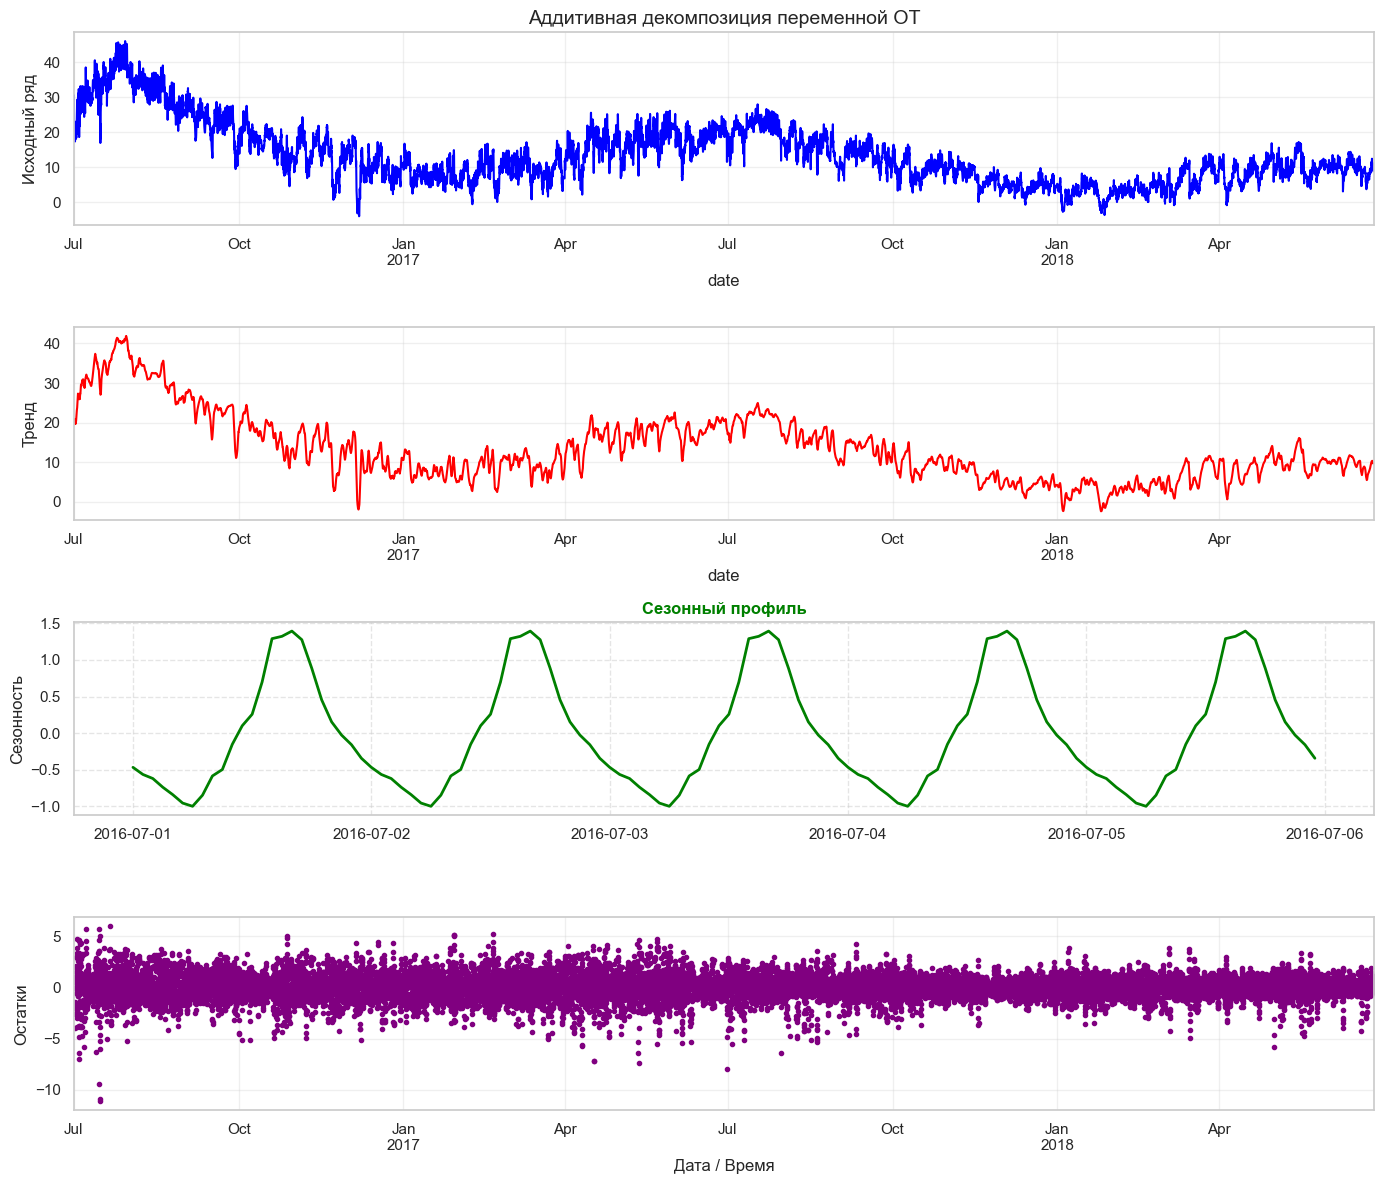

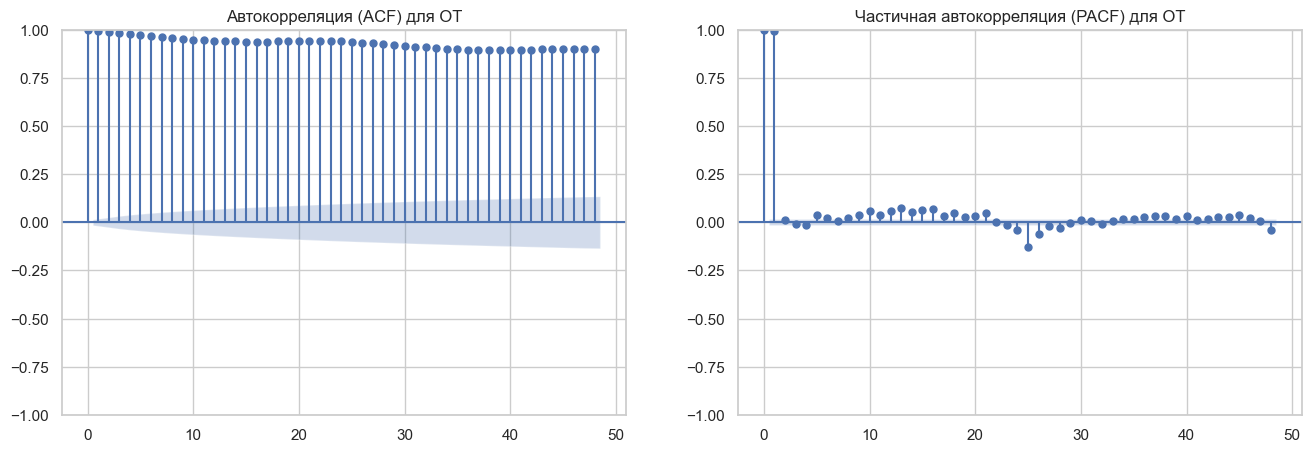

In [3]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import StandardScaler

target_col = 'OT'

print("=== 3. Декомпозиция ряда ===")
period = 24
decomposition = seasonal_decompose(df[target_col], model='additive', period=period)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12))

decomposition.observed.plot(ax=ax1, color='blue', legend=False)
ax1.set_ylabel('Исходный ряд')
ax1.set_title(f'Аддитивная декомпозиция переменной {target_col}', fontsize=14)
ax1.grid(True, alpha=0.3)

decomposition.trend.plot(ax=ax2, color='red', legend=False)
ax2.set_ylabel('Тренд')
ax2.grid(True, alpha=0.3)


seasonal_slice = decomposition.seasonal.iloc[:24 * 5] 
ax3.plot(seasonal_slice.index, seasonal_slice.values, color='green', linewidth=2)
ax3.set_ylabel('Сезонность')
ax3.set_title('Сезонный профиль', color='green', fontweight='bold')
ax3.grid(True, alpha=0.5, linestyle='--')


import matplotlib.dates as mdates
ax3.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax3.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))


decomposition.resid.plot(ax=ax4, color='purple', legend=False, style='.')
ax4.set_ylabel('Остатки')
ax4.grid(True, alpha=0.3)

plt.xlabel('Дата / Время')
plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(df['OT'], lags=48, ax=ax1)
ax1.set_title('Автокорреляция (ACF) для OT')
plot_pacf(df['OT'], lags=48, ax=ax2, method='ywm')
ax2.set_title('Частичная автокорреляция (PACF) для OT')
plt.show()

### Предобработка врем.ряда

In [22]:

cols_to_drop = ['HUFL.1', 'HULL.1', 'MUFL.1', 'MULL.1', 'LUFL.1', 'LULL.1', 'OT.1']
df_features = df.copy().drop(columns=cols_to_drop)
target_col = 'OT'

print(f"Исходное количество признаков: {df_features.shape[1] - 1}")


lags = [1, 3, 6, 12, 24]
for lag in lags:
    df_features[f'{target_col}_lag_{lag}'] = df_features[target_col].shift(lag)



shifted_target = df_features[target_col].shift(1)
windows = [6, 24]
for w in windows:
    df_features[f'{target_col}_roll_mean_{w}'] = shifted_target.rolling(window=w).mean()
    df_features[f'{target_col}_roll_std_{w}'] = shifted_target.rolling(window=w).std()
    df_features[f'{target_col}_roll_max_{w}'] = shifted_target.rolling(window=w).max()
    df_features[f'{target_col}_roll_min_{w}'] = shifted_target.rolling(window=w).min()


def get_fft_amplitude(window):
    if np.isnan(window).any():
        return np.nan
    f_transform = fft(window)
    return np.abs(f_transform[1]) if len(f_transform) > 1 else 0

df_features[f'{target_col}_fft_amp_24'] = shifted_target.rolling(window=24).apply(get_fft_amplitude, raw=True)


print(f"Форма датасета ДО удаления строк с NaN: {df_features.shape}")
df_features.dropna(inplace=True)
print(f"Форма датасета ПОСЛЕ удаления строк с NaN: {df_features.shape}")

print(f"\nИтоговое количество признаков для обучения моделей: {df_features.shape[1] - 1}")
print("\nСписок сгенерированных новых колонок (примеры):")
print([col for col in df_features.columns if col not in df.columns][:15])

Исходное количество признаков: 6
Форма датасета ДО удаления строк с NaN: (17420, 21)
Форма датасета ПОСЛЕ удаления строк с NaN: (17396, 21)

Итоговое количество признаков для обучения моделей: 20

Список сгенерированных новых колонок (примеры):
['OT_lag_1', 'OT_lag_3', 'OT_lag_6', 'OT_lag_12', 'OT_lag_24', 'OT_roll_mean_6', 'OT_roll_std_6', 'OT_roll_max_6', 'OT_roll_min_6', 'OT_roll_mean_24', 'OT_roll_std_24', 'OT_roll_max_24', 'OT_roll_min_24', 'OT_fft_amp_24']


In [7]:
X = df_features.copy()


train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

train_df = X.iloc[:train_size]
val_df = X.iloc[train_size:train_size + val_size]
test_df = X.iloc[train_size + val_size:]

print("\n--- Разделение выборки ---")
print(f"Train: {train_df.shape[0]} строк")
print(f"Validation: {val_df.shape[0]} строк")
print(f"Test: {test_df.shape[0]} строк")

print("\n--- Масштабирование признаков ---")
scaler = MinMaxScaler()

scaler.fit(train_df)

train_scaled = pd.DataFrame(scaler.transform(train_df), columns=train_df.columns, index=train_df.index)
val_scaled = pd.DataFrame(scaler.transform(val_df), columns=val_df.columns, index=val_df.index)
test_scaled = pd.DataFrame(scaler.transform(test_df), columns=test_df.columns, index=test_df.index)

print("Пример преобразованных данных (первые 3 строки train):")
print(train_scaled.iloc[:3, ])

cols_to_drop = ['OT']
X_train, y_train = train_scaled.copy().drop(columns=cols_to_drop), train_scaled.copy()['OT']
X_val, y_val = val_scaled.copy().drop(columns=cols_to_drop), val_scaled.copy()['OT']
X_test, y_test = test_scaled.copy().drop(columns=cols_to_drop), test_scaled.copy()['OT']


--- Разделение выборки ---
Train: 12177 строк
Validation: 2609 строк
Test: 2610 строк

--- Шаг 3: Масштабирование признаков ---
Данные успешно отмасштабированы.
Пример преобразованных данных (первые 3 строки train):
                         HUFL      HULL      MUFL      MULL      LUFL  \
date                                                                    
2016-07-02 00:00:00  0.574291  0.527034  0.627500  0.536844  0.374251   
2016-07-02 01:00:00  0.572743  0.522529  0.632003  0.539436  0.364753   
2016-07-02 02:00:00  0.572743  0.531540  0.632003  0.549952  0.358455   

                         LULL        OT  OT_lag_1  OT_lag_3  OT_lag_6  ...  \
date                                                                   ...   
2016-07-02 00:00:00  0.655196  0.502805  0.476132  0.441013  0.494380  ...   
2016-07-02 01:00:00  0.634594  0.474714  0.502805  0.441013  0.455048  ...   
2016-07-02 02:00:00  0.634594  0.481742  0.474714  0.476132  0.438198  ...   

                     OT_la

### Random Forest

In [8]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results_table = []

def evaluate_forecast(y_true, y_pred, model_name="Модель"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"=== Результаты для {model_name} ===")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}\n")

    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "R2": r2}

=== Размеры выборок для Случайного Леса ===
Обучающая (X_train): (12177, 20)
Валидационная (X_val): (2609, 20)
Тестовая (X_test): (2610, 20)

Обучение модели Random Forest... (это может занять около минуты)
Модель успешно обучена!

=== Результаты для Random Forest ===
MAE:  0.0095
RMSE: 0.0137
R²:   0.9417

Для справки -> MAE на Train: 0.0089
Для справки -> MAE на Validation: 0.0110



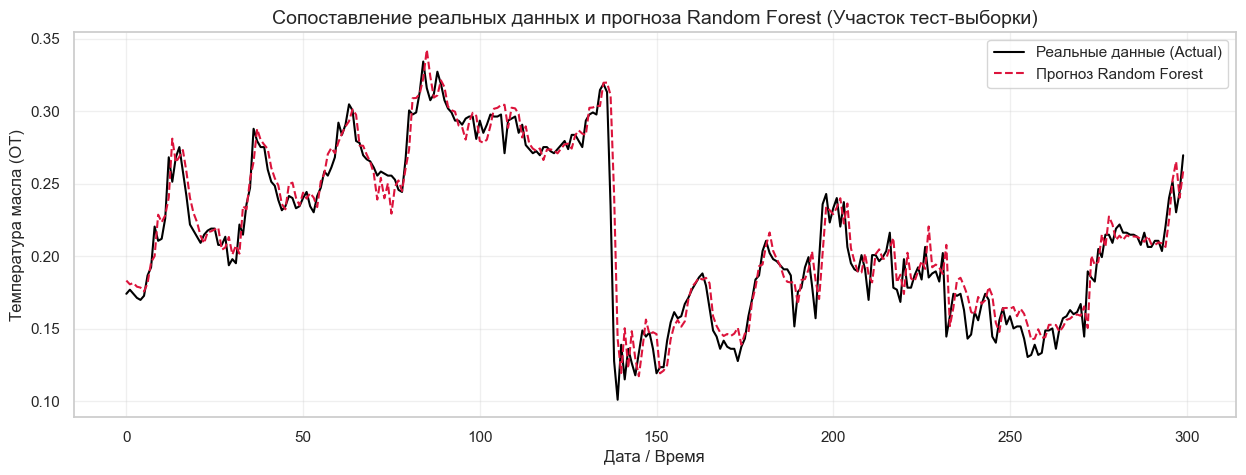

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

print("Обучение модели Random Forest...")

rf_model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Модель обучена!\n")

y_pred_train = rf_model.predict(X_train)
y_pred_val = rf_model.predict(X_val)
y_pred_test = rf_model.predict(X_test)
rf_pred = y_pred_test


rf_metrics = evaluate_forecast(y_test, y_pred_test, model_name="Random Forest")
results_table.append(rf_metrics)


print(f"MAE на Train: {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"MAE на Validation: {mean_absolute_error(y_val, y_pred_val):.4f}\n")


plt.figure(figsize=(15, 5))
plt.plot(y_test.values[:300], label='Реальные данные (Actual)', color='black', linewidth=1.5)
plt.plot(y_pred_test[:300], label='Прогноз Random Forest', color='crimson', linestyle='--', linewidth=1.5)
plt.title('Сопоставление реальных данных и прогноза Random Forest (Участок тест-выборки)', fontsize=14)
plt.xlabel('Дата / Время')
plt.ylabel('Температура масла (OT)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### LSTM

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 
                      ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Используемое устройство: {device}")

cols_to_drop = ['HUFL.1', 'HULL.1', 'MUFL.1', 'MULL.1', 'LUFL.1', 'LULL.1', 'OT.1']
df_nn = X.copy()

target_col = 'OT'
X_raw = df_nn.drop(columns=[target_col, 'OT.1'] if 'OT.1' in df_nn.columns else [target_col])
y_raw = df_nn[[target_col]]


train_size = int(len(df_nn) * 0.70)
val_size = int(len(df_nn) * 0.15)

X_train_raw, y_train_raw = X_raw.iloc[:train_size], y_raw.iloc[:train_size]
X_val_raw, y_val_raw = X_raw.iloc[train_size:train_size + val_size], y_raw.iloc[train_size:train_size + val_size]
X_test_raw, y_test_raw = X_raw.iloc[train_size + val_size:], y_raw.iloc[train_size + val_size:]

scaler_X, scaler_y = MinMaxScaler(), MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train_raw)
y_train_scaled = scaler_y.fit_transform(y_train_raw)

X_val_scaled = scaler_X.transform(X_val_raw)
y_val_scaled = scaler_y.transform(y_val_raw)

X_test_scaled = scaler_X.transform(X_test_raw)
y_test_scaled = scaler_y.transform(y_test_raw)


def create_3d_dataset(X_data, y_data, look_back=24):
    X_3d, y_3d = [], []
    for i in range(len(X_data) - look_back):
        X_3d.append(X_data[i : (i + look_back)])
        y_3d.append(y_data[i + look_back])
    return np.array(X_3d), np.array(y_3d)

look_back = 24
X_train_3d, y_train_3d = create_3d_dataset(X_train_scaled, y_train_scaled, look_back)
X_val_3d, y_val_3d = create_3d_dataset(X_val_scaled, y_val_scaled, look_back)
X_test_3d, y_test_3d = create_3d_dataset(X_test_scaled, y_test_scaled, look_back)


X_train_t = torch.tensor(X_train_3d, dtype=torch.float32)
y_train_t = torch.tensor(y_train_3d, dtype=torch.float32)

X_val_t = torch.tensor(X_val_3d, dtype=torch.float32)
y_val_t = torch.tensor(y_val_3d, dtype=torch.float32)

X_test_t = torch.tensor(X_test_3d, dtype=torch.float32)
y_test_t = torch.tensor(y_test_3d, dtype=torch.float32)


batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

print(f"Размер обучающего тензора: {X_train_t.shape}")

Используемое устройство: cuda
Размер обучающего тензора: torch.Size([12153, 24, 20])


In [11]:
class StackedLSTM(nn.Module):
    def __init__(self, input_size):
        super(StackedLSTM, self).__init__()

        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=64, batch_first=True)
        self.dropout1 = nn.Dropout(0.2)
        
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=32, batch_first=True)
        self.dropout2 = nn.Dropout(0.2)
        
        self.fc1 = nn.Linear(32, 16)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        
        out, _ = self.lstm2(out)
        
        out = out[:, -1, :] 
        
        out = self.dropout2(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        return out

num_features = X_train_t.shape[2]
model_lstm = StackedLSTM(input_size=num_features).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

epochs = 30
patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

history = {'train_loss': [], 'val_loss': []}

print("\nЗапуск обучения LSTM")
for epoch in range(epochs):
    # --- Фаза обучения ---
    model_lstm.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()          
        outputs = model_lstm(X_batch)  
        loss = criterion(outputs, y_batch)
        loss.backward()                
        optimizer.step()               
        
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)
    
    
    model_lstm.eval()
    val_loss = 0.0
    with torch.no_grad(): 
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_lstm(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)
    
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    print(f"Эпоха {epoch+1:02d}/{epochs} -> Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    best_val_loss = val_loss
    patience_counter = 0
    best_model_state = model_lstm.state_dict()


if best_model_state is not None:
    model_lstm.load_state_dict(best_model_state)


Запуск обучения LSTM на PyTorch...
Эпоха 01/30 -> Train Loss: 0.007693 | Val Loss: 0.001861
Эпоха 02/30 -> Train Loss: 0.002406 | Val Loss: 0.001235
Эпоха 03/30 -> Train Loss: 0.002026 | Val Loss: 0.001237
Эпоха 04/30 -> Train Loss: 0.001657 | Val Loss: 0.001062
Эпоха 05/30 -> Train Loss: 0.001503 | Val Loss: 0.001125
Эпоха 06/30 -> Train Loss: 0.001373 | Val Loss: 0.001285
Эпоха 07/30 -> Train Loss: 0.001288 | Val Loss: 0.000468
Эпоха 08/30 -> Train Loss: 0.001232 | Val Loss: 0.000870
Эпоха 09/30 -> Train Loss: 0.001221 | Val Loss: 0.000340
Эпоха 10/30 -> Train Loss: 0.001121 | Val Loss: 0.000540
Эпоха 11/30 -> Train Loss: 0.001087 | Val Loss: 0.000295
Эпоха 12/30 -> Train Loss: 0.001063 | Val Loss: 0.000323
Эпоха 13/30 -> Train Loss: 0.001026 | Val Loss: 0.000618
Эпоха 14/30 -> Train Loss: 0.001020 | Val Loss: 0.000491
Эпоха 15/30 -> Train Loss: 0.000958 | Val Loss: 0.000562
Эпоха 16/30 -> Train Loss: 0.000942 | Val Loss: 0.000482
Эпоха 17/30 -> Train Loss: 0.000957 | Val Loss: 0.00

=== Результаты для LSTM (PyTorch) ===
MAE:  0.6038
RMSE: 0.8821
R²:   0.9033



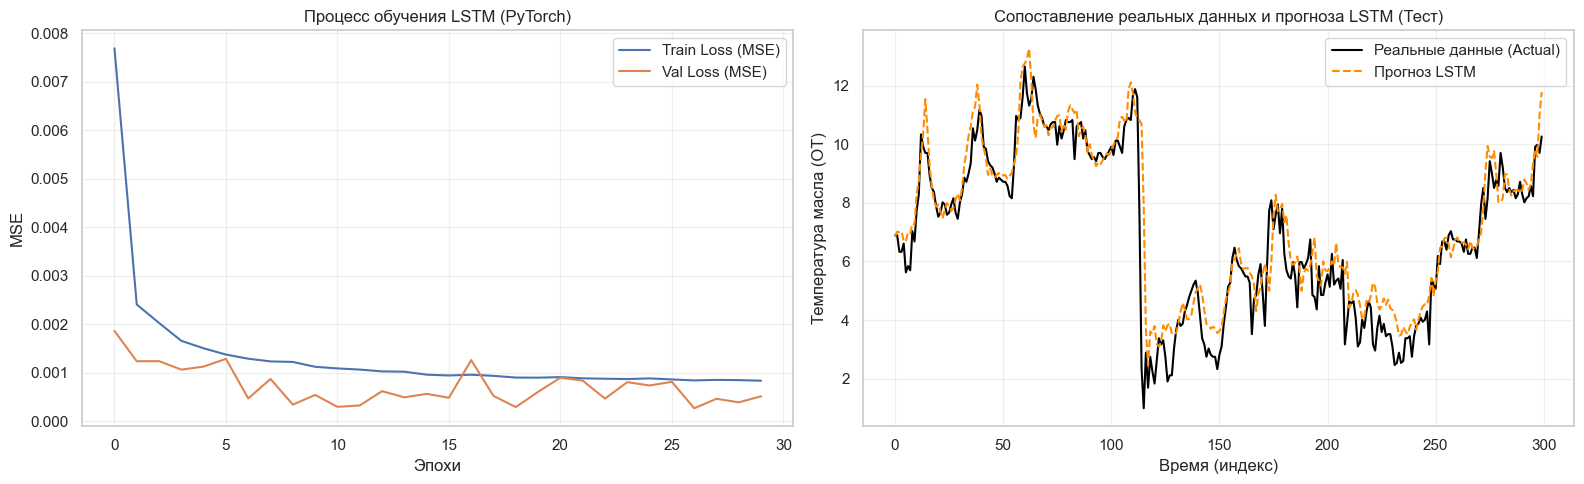

In [12]:
model_lstm.eval()
y_preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_lstm(X_batch)
        y_preds.append(outputs.cpu().numpy())


y_pred_scaled = np.vstack(y_preds)


y_pred_unscaled = scaler_y.inverse_transform(y_pred_scaled)
y_test_unscaled = scaler_y.inverse_transform(y_test_t.numpy())
lstm_pred = y_pred_unscaled


lstm_metrics = evaluate_forecast(y_test_unscaled, y_pred_unscaled, model_name="LSTM")
results_table.append(lstm_metrics)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))


ax1.plot(history['train_loss'], label='Train Loss (MSE)')
ax1.plot(history['val_loss'], label='Val Loss (MSE)')
ax1.set_title('Процесс обучения LSTM')
ax1.set_xlabel('Эпохи')
ax1.set_ylabel('MSE')
ax1.legend()
ax1.grid(True, alpha=0.3)


ax2.plot(y_test_unscaled[:300], label='Реальные данные (Actual)', color='black', linewidth=1.5)
ax2.plot(y_pred_unscaled[:300], label='Прогноз LSTM', color='darkorange', linestyle='--', linewidth=1.5)
ax2.set_title('Сопоставление реальных данных и прогноза LSTM (Тест)')
ax2.set_xlabel('Время (индекс)')
ax2.set_ylabel('Температура масла (OT)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### CNN

In [13]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


torch.manual_seed(4)
np.random.seed(42)


print(f"Используемое устройство: {device}")

class TimeSeries1DCNN(nn.Module):
    def __init__(self, input_size, seq_len):
        super(TimeSeries1DCNN, self).__init__()
        
        
        self.conv1 = nn.Conv1d(in_channels=input_size, out_channels=64, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2)
        

        self.conv2 = nn.Conv1d(in_channels=64, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2)
        

        self.flatten = nn.Flatten()
        

        self.fc1 = nn.Linear(32 * seq_len, 32)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):

        x = x.permute(0, 2, 1)
        

        x = self.dropout1(self.relu1(self.conv1(x)))
        x = self.dropout2(self.relu2(self.conv2(x)))
        

        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x


num_features = X_train_t.shape[2]
model_cnn = TimeSeries1DCNN(input_size=num_features, seq_len=look_back).to(device)


criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=0.001)


epochs = 30
patience = 5
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

history_cnn = {'train_loss': [], 'val_loss': []}

print("\nЗапуск обучения 1D-CNN")
for epoch in range(epochs):
    model_cnn.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model_cnn(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
    train_loss /= len(train_loader.dataset)
    
    model_cnn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model_cnn(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(val_loader.dataset)
    
    history_cnn['train_loss'].append(train_loss)
    history_cnn['val_loss'].append(val_loss)
    
    print(f"Эпоха {epoch+1:02d}/{epochs} -> Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    best_val_loss = val_loss
    patience_counter = 0
    best_model_state = model_cnn.state_dict()

if best_model_state is not None:
    model_cnn.load_state_dict(best_model_state)


Используемое устройство: cuda

Запуск обучения 1D-CNN на PyTorch...
Эпоха 01/30 -> Train Loss: 0.008531 | Val Loss: 0.001634
Эпоха 02/30 -> Train Loss: 0.002546 | Val Loss: 0.000680
Эпоха 03/30 -> Train Loss: 0.002147 | Val Loss: 0.002040
Эпоха 04/30 -> Train Loss: 0.001988 | Val Loss: 0.000840
Эпоха 05/30 -> Train Loss: 0.001803 | Val Loss: 0.000694
Эпоха 06/30 -> Train Loss: 0.001768 | Val Loss: 0.000672
Эпоха 07/30 -> Train Loss: 0.001623 | Val Loss: 0.000686
Эпоха 08/30 -> Train Loss: 0.001537 | Val Loss: 0.000487
Эпоха 09/30 -> Train Loss: 0.001493 | Val Loss: 0.000502
Эпоха 10/30 -> Train Loss: 0.001333 | Val Loss: 0.000556
Эпоха 11/30 -> Train Loss: 0.001452 | Val Loss: 0.000877
Эпоха 12/30 -> Train Loss: 0.001391 | Val Loss: 0.000513
Эпоха 13/30 -> Train Loss: 0.001227 | Val Loss: 0.000924
Эпоха 14/30 -> Train Loss: 0.001229 | Val Loss: 0.000468
Эпоха 15/30 -> Train Loss: 0.001290 | Val Loss: 0.000885
Эпоха 16/30 -> Train Loss: 0.001170 | Val Loss: 0.000836
Эпоха 17/30 -> Train

=== Результаты для 1D-CNN (PyTorch) ===
MAE:  0.7345
RMSE: 1.0177
R²:   0.8713



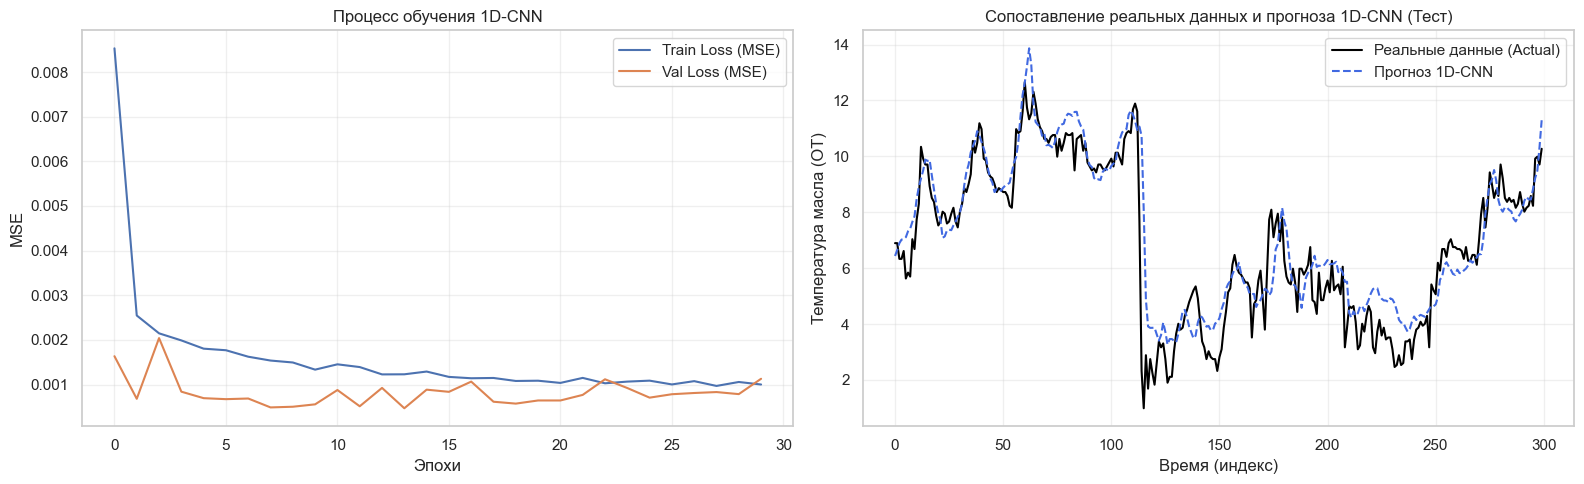

In [14]:
model_cnn.eval()
y_preds = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_cnn(X_batch)
        y_preds.append(outputs.cpu().numpy())

y_pred_scaled = np.vstack(y_preds)


y_pred_unscaled = scaler_y.inverse_transform(y_pred_scaled)
cnn_pred = y_pred_unscaled


cnn_metrics = evaluate_forecast(y_test_unscaled, y_pred_unscaled, model_name="1D-CNN")
results_table.append(cnn_metrics)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))


ax1.plot(history_cnn['train_loss'], label='Train Loss (MSE)')
ax1.plot(history_cnn['val_loss'], label='Val Loss (MSE)')
ax1.set_title('Процесс обучения 1D-CNN')
ax1.set_xlabel('Эпохи')
ax1.set_ylabel('MSE')
ax1.legend()
ax1.grid(True, alpha=0.3)


ax2.plot(y_test_unscaled[:300], label='Реальные данные (Actual)', color='black', linewidth=1.5)
ax2.plot(y_pred_unscaled[:300], label='Прогноз 1D-CNN', color='royalblue', linestyle='--', linewidth=1.5)
ax2.set_title('Сопоставление реальных данных и прогноза 1D-CNN (Тест)')
ax2.set_xlabel('Время (индекс)')
ax2.set_ylabel('Температура масла (OT)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
for i in results_table:
    print(i)

{'Model': 'Random Forest', 'MAE': 0.009487218190286003, 'RMSE': np.float64(0.013678751903396071), 'R2': 0.9416797289324171}
{'Model': 'LSTM (PyTorch)', 'MAE': 0.6037580370903015, 'RMSE': np.float64(0.8821006875965572), 'R2': 0.9032966494560242}
{'Model': '1D-CNN (PyTorch)', 'MAE': 0.7344944477081299, 'RMSE': np.float64(1.0177316970772394), 'R2': 0.8712723255157471}


In [20]:
rf_pred = scaler_y.inverse_transform(rf_pred.reshape(-1, 1))

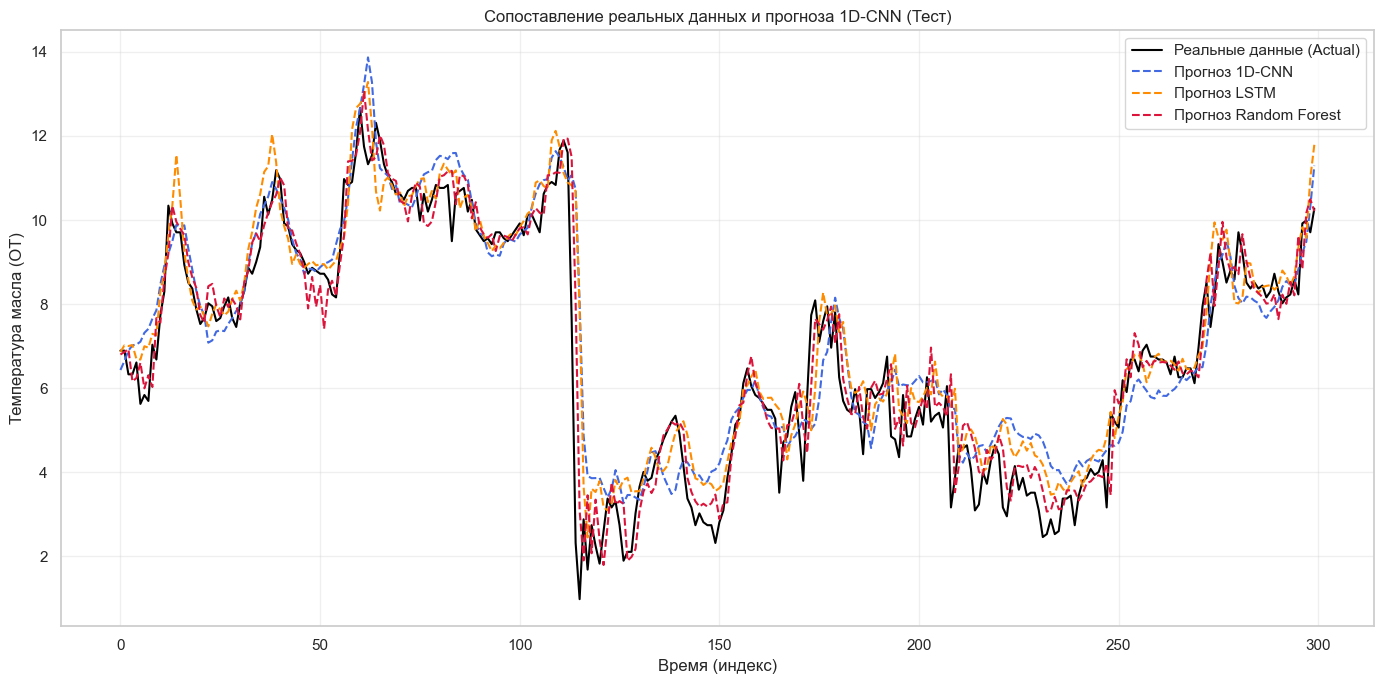

In [21]:

plt.plot(y_test_unscaled[:300], label='Реальные данные (Actual)', color='black', linewidth=1.5)
plt.plot(cnn_pred[:300], label='Прогноз 1D-CNN', color='royalblue', linestyle='--', linewidth=1.5)
plt.plot(lstm_pred[:300], label='Прогноз LSTM', color='darkorange', linestyle='--', linewidth=1.5)
plt.plot(rf_pred[24:324], label='Прогноз Random Forest', color='crimson', linestyle='--', linewidth=1.5)
plt.title('Сопоставление реальных данных и прогноза 1D-CNN (Тест)')
plt.xlabel('Время (индекс)')
plt.ylabel('Температура масла (OT)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Лучше всего себя показал себя случайный лес(нейросети показали себя не сильно хуже). Временной ряд небольшой(17000 строк) поэтому класический мл показал себя не хуже нейронок.
